In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data preparing

## 1 GPU

In [14]:
res_1gpu = pd.read_csv('bioemu_results.csv')

res_1gpu.head()

,job_id,node,rank,n_gpus,gpu_name,seq_range,fasta_file,seq_len,phase,cache_warm,num_samples,batch_size,wall_time_s,peak_vram_mb,status
0,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,warmup,False,1,10,41.52,159.7,ok
1,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,10,22.38,829.7,ok
2,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,20,20.32,1544.7,ok
3,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,50,18.62,2518.6,ok
4,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000609_01331.fasta,69,warmup,False,1,10,23.28,170.8,ok


In [8]:
res_1gpu.shape

(699, 15)

In [ ]:
res_1gpu_ok = res_1gpu[res_1gpu["status"] == "ok"]

In [10]:
res_1gpu_ok.shape

(532, 15)

In [53]:
res_1gpu_ok_warmup = res_1gpu_ok[res_1gpu_ok["phase"] == "warmup"]
res_1gpu_ok_warmup.shape

(133, 15)

Actual runs:

In [54]:
res_1gpu_ok = res_1gpu_ok[res_1gpu_ok["phase"] != "warmup"]
res_1gpu_ok.shape

(399, 15)

Divide by batch_size:

In [65]:
res_1gpu_ok_bs10 = res_1gpu_ok[res_1gpu_ok["batch_size"] == 10]
res_1gpu_ok_bs20 = res_1gpu_ok[res_1gpu_ok["batch_size"] == 20]
res_1gpu_ok_bs50 = res_1gpu_ok[res_1gpu_ok["batch_size"] == 50]


## 8 GPU

In [15]:
res_8gpu = pd.read_csv('bioemu_results_8gpu.csv')

res_8gpu.head()

,job_id,node,rank,n_gpus,gpu_name,seq_range,fasta_file,seq_len,phase,cache_warm,num_samples,batch_size,wall_time_s,peak_vram_mb,status
0,2631559,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,warmup,False,1,10,8.96,0.0,ok
1,2631559,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,10,26.04,0.0,ok
2,2631559,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,20,27.66,0.0,ok
3,2631559,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,50,24.59,0.0,ok
4,2631559,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000002467_02821.fasta,63,warmup,False,1,10,7.98,0.0,ok


In [16]:
res_8gpu.shape

(699, 15)

In [17]:
res_8gpu_ok = res_8gpu[res_8gpu["status"] == "ok"]

In [18]:
res_8gpu_ok.shape

(532, 15)

In [56]:
res_8gpu_ok_warmup = res_8gpu_ok[res_8gpu_ok["phase"] == "warmup"]
res_8gpu_ok_warmup.shape

(133, 15)

In [58]:
res_8gpu_ok = res_8gpu_ok[res_8gpu_ok["phase"] != "warmup"]
res_8gpu_ok.shape

(399, 15)

Divide by batch_size:

In [71]:
res_8gpu_ok_bs10 = res_8gpu_ok[res_8gpu_ok["batch_size"] == 10]
res_8gpu_ok_bs20 = res_8gpu_ok[res_8gpu_ok["batch_size"] == 20]
res_8gpu_ok_bs50 = res_8gpu_ok[res_8gpu_ok["batch_size"] == 50]

## Multinode

In [19]:
res_multi = pd.read_csv('bioemu_results_multinode.csv')

res_multi.head()

,job_id,node,rank,n_gpus,gpu_name,seq_range,fasta_file,seq_len,phase,cache_warm,num_samples,batch_size,wall_time_s,peak_vram_mb,status
0,2631560,"t[0007,0017-0019]",0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,warmup,False,1,10,9.31,0.0,ok
1,2631560,"t[0007,0017-0019]",0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,10,29.08,0.0,ok
2,2631560,"t[0007,0017-0019]",0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,20,26.34,0.0,ok
3,2631560,"t[0007,0017-0019]",0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000000010_00108.fasta,58,sample,True,100,50,28.15,0.0,ok
4,2631560,"t[0007,0017-0019]",0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000047567_01789.fasta,87,warmup,False,1,10,9.62,0.0,ok


In [ ]:
res_multi.shape

(699, 15)

In [21]:
res_multi_ok = res_multi[res_multi["status"] == "ok"]

In [22]:
res_multi_ok.shape

(532, 15)

In [59]:
res_multi_ok_warmup = res_multi_ok[res_multi_ok["phase"] == "warmup"]
res_multi_ok_warmup.shape

(133, 15)

In [60]:
res_multi_ok = res_multi_ok[res_multi_ok["phase"] != "warmup"]
res_multi_ok.shape

(399, 15)

Divide by batch_size:

In [70]:
res_multi_ok_bs10 = res_multi_ok[res_multi_ok["batch_size"] == 10]
res_multi_ok_bs20 = res_multi_ok[res_multi_ok["batch_size"] == 20]
res_multi_ok_bs50 = res_multi_ok[res_multi_ok["batch_size"] == 50]

## ERRORS

error_class   ok  range_zero  unphysical_xtc. 
50-100aa      80      0           20. 
101-500aa     53     28           19. 
501-1000aa     0    100            0. 

Good results:

In [44]:
print("50-100aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "50-100aa"].shape[0]/4) # 4 runs for every protein
print("101-500aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "101-500aa"].shape[0]/4)
print("501-1000aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "501-1000aa"].shape[0]/4)

50-100aa:  80.0
101-500aa:  53.0
501-1000aa:  0.0


/var/folders/5n/w81s25bs2g55vdyflwkb6k640000gn/T/ipykernel_46487/703857815.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("50-100aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "50-100aa"].shape[0]/4) # 4 runs for every protein
/var/folders/5n/w81s25bs2g55vdyflwkb6k640000gn/T/ipykernel_46487/703857815.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("101-500aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "101-500aa"].shape[0]/4)
/var/folders/5n/w81s25bs2g55vdyflwkb6k640000gn/T/ipykernel_46487/703857815.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("501-1000aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "501-1000aa"].shape[0]/4)


In [23]:
error_proteins = res_1gpu[res_1gpu["status"] != "ok"]

In [24]:
error_proteins

,job_id,node,rank,n_gpus,gpu_name,seq_range,fasta_file,seq_len,phase,cache_warm,num_samples,batch_size,wall_time_s,peak_vram_mb,status
12,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000001644_00452.fasta,86,warmup,False,1,10,14.39,220.1,ERROR: Invalid suffix '_unphysical.xtc'
21,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000002314_04241.fasta,59,warmup,False,1,10,12.66,185.0,ERROR: Invalid suffix '_unphysical.xtc'
42,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000003710_00836.fasta,66,warmup,False,1,10,13.55,167.1,ERROR: Invalid suffix '_unphysical.xtc'
71,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000014506_03467.fasta,97,warmup,False,1,10,13.02,264.4,ERROR: Invalid suffix '_unphysical.xtc'
120,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,50-100aa,MGYG000049005_01050.fasta,91,warmup,False,1,10,59.54,194.1,ERROR: Invalid suffix '_unphysical.xtc'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,501-1000aa,MGYG000278373_01737.fasta,607,warmup,False,1,10,0.54,62.0,ERROR: range() arg 3 must not be zero
695,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,501-1000aa,MGYG000278652_00276.fasta,561,warmup,False,1,10,0.54,62.0,ERROR: range() arg 3 must not be zero
696,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,501-1000aa,MGYG000283754_00968.fasta,777,warmup,False,1,10,0.55,62.0,ERROR: range() arg 3 must not be zero
697,2631537,t0014,0,1,NVIDIA A100-SXM4-40GB,501-1000aa,MGYG000285861_01081.fasta,816,warmup,False,1,10,0.54,62.0,ERROR: range() arg 3 must not be zero


In [25]:
error_proteins_range = error_proteins[error_proteins["status"] == "ERROR: range() arg 3 must not be zero"]
error_proteins_unphysical = error_proteins[error_proteins["status"] == "ERROR: Invalid suffix '_unphysical.xtc'"]

In [ ]:
print(error_proteins_range.shape)
print(error_proteins_unphysical.shape)

(128, 15)
(39, 15)


In [38]:
error_proteins_range['seq_len'].min() # the shortest protein with error

np.int64(319)

In [39]:
res_1gpu_ok['seq_len'].max() # the longest protein that gave results

np.int64(314)

In [47]:
print("Good results:")
print("50-100aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "50-100aa"].shape[0]/4) # 4 runs for every protein (warmup and 3 batch sizes)
print("101-500aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "101-500aa"].shape[0]/4)
print("501-1000aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "501-1000aa"].shape[0]/4)

print("Range error:")
print("50-100aa: ", error_proteins_range[error_proteins_range["seq_range"] == "50-100aa"].shape[0])
print("101-500aa: ", error_proteins_range[error_proteins_range["seq_range"] == "101-500aa"].shape[0])
print("501-1000aa: ", error_proteins_range[error_proteins_range["seq_range"] == "501-1000aa"].shape[0])

print("Unphysical error:")
print("50-100aa: ", error_proteins_unphysical[error_proteins_unphysical["seq_range"] == "50-100aa"].shape[0])
print("101-500aa: ", error_proteins_unphysical[error_proteins_unphysical["seq_range"] == "101-500aa"].shape[0])
print("501-1000aa: ", error_proteins_unphysical[error_proteins_unphysical["seq_range"] == "501-1000aa"].shape[0])

Good results:
50-100aa:  80.0
101-500aa:  53.0
501-1000aa:  0.0
Range error:
50-100aa:  0
101-500aa:  28
501-1000aa:  100
Unphysical error:
50-100aa:  20
101-500aa:  19
501-1000aa:  0


/var/folders/5n/w81s25bs2g55vdyflwkb6k640000gn/T/ipykernel_46487/1895769514.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("50-100aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "50-100aa"].shape[0]/4) # 4 runs for every protein (warmup and 3 batch sizes)
/var/folders/5n/w81s25bs2g55vdyflwkb6k640000gn/T/ipykernel_46487/1895769514.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("101-500aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "101-500aa"].shape[0]/4)
/var/folders/5n/w81s25bs2g55vdyflwkb6k640000gn/T/ipykernel_46487/1895769514.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print("501-1000aa: ", res_1gpu_ok[res_1gpu["seq_range"] == "501-1000aa"].shape[0]/4)


In [49]:
error_data = {
    "class": ["50-100aa", "101-500aa", "501-1000aa"],
    "ok": [80, 53, 0],
    "range error": [0, 28, 100],
    "unphysical error": [20, 19, 0]
}

error_data = pd.DataFrame(error_data)
error_data

,class,ok,range error,unphysical error
0,50-100aa,80,0,20
1,101-500aa,53,28,19
2,501-1000aa,0,100,0


Conclusions: 
- Proteins with >314aa return a 'range error'
- Some proteins returned an 'unphysical error', because we used filter_samples=True and all samples got rejected

# Benchmark

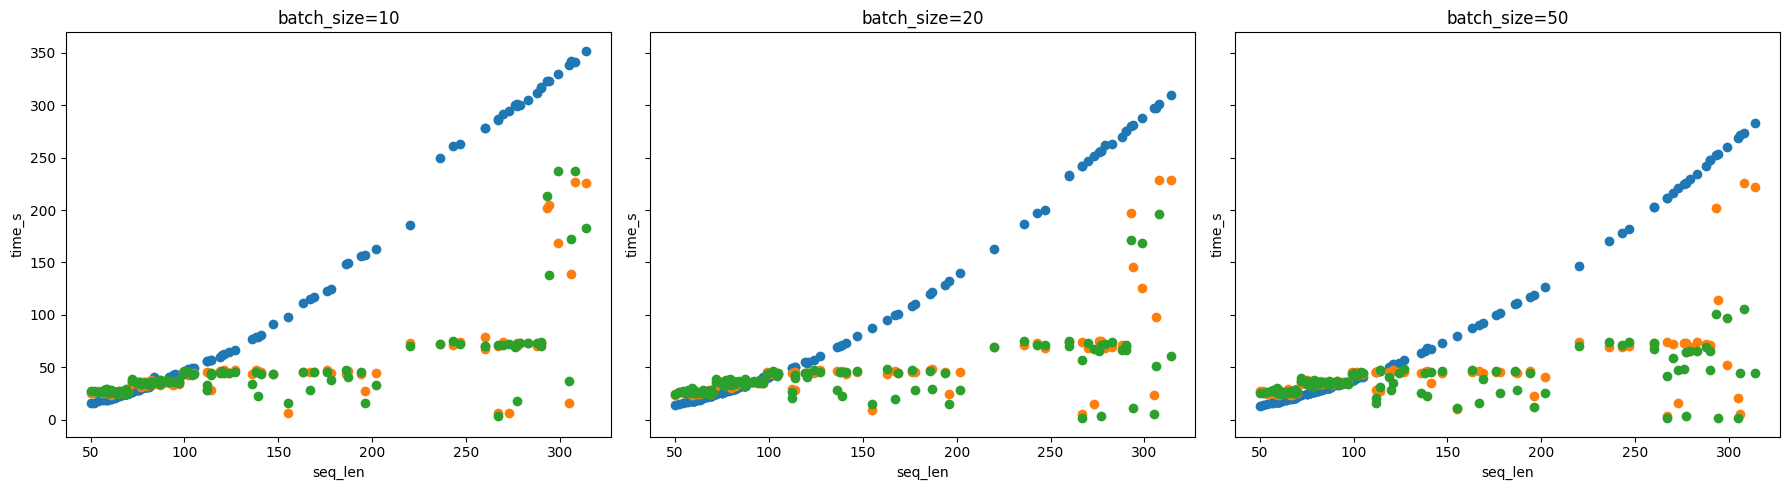

In [98]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(res_1gpu_ok_bs10["seq_len"], res_1gpu_ok_bs10["wall_time_s"])
axes[0].scatter(res_8gpu_ok_bs10["seq_len"], res_8gpu_ok_bs10["wall_time_s"])
axes[0].scatter(res_multi_ok_bs10["seq_len"], res_multi_ok_bs10["wall_time_s"])
axes[0].set_title("batch_size=10")

axes[1].scatter(res_1gpu_ok_bs20["seq_len"], res_1gpu_ok_bs20["wall_time_s"])
axes[1].scatter(res_8gpu_ok_bs20["seq_len"], res_8gpu_ok_bs20["wall_time_s"])
axes[1].scatter(res_multi_ok_bs20["seq_len"], res_multi_ok_bs20["wall_time_s"])
axes[1].set_title("batch_size=20")

axes[2].scatter(res_1gpu_ok_bs50["seq_len"], res_1gpu_ok_bs50["wall_time_s"])
axes[2].scatter(res_8gpu_ok_bs50["seq_len"], res_8gpu_ok_bs50["wall_time_s"])
axes[2].scatter(res_multi_ok_bs50["seq_len"], res_multi_ok_bs50["wall_time_s"])
axes[2].set_title("batch_size=50")

for ax in axes:
    ax.set_xlabel("seq_len")
    ax.set_ylabel("time_s")

plt.tight_layout()
plt.show()

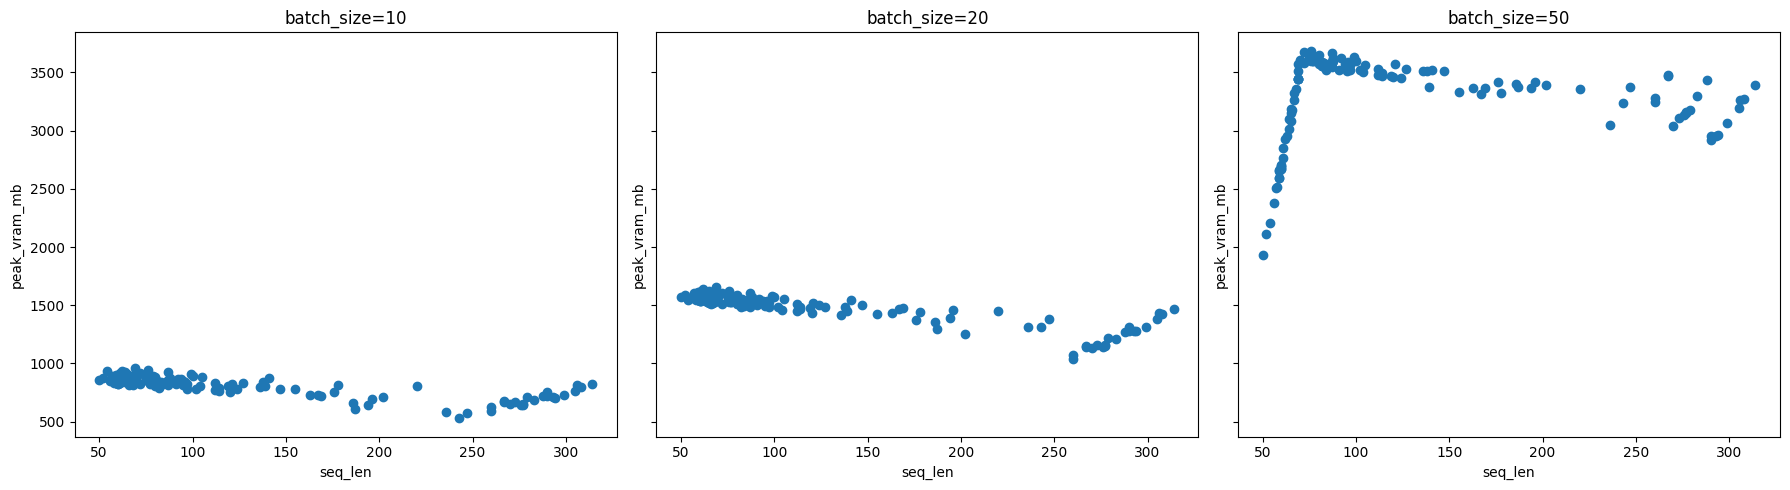

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(res_1gpu_ok_bs10["seq_len"], res_1gpu_ok_bs10["peak_vram_mb"])
#axes[0].scatter(res_8gpu_ok_bs10["seq_len"], res_8gpu_ok_bs10["peak_vram_mb"])
#axes[0].scatter(res_multi_ok_bs10["seq_len"], res_multi_ok_bs10["peak_vram_mb"])
axes[0].set_title("batch_size=10")

axes[1].scatter(res_1gpu_ok_bs20["seq_len"], res_1gpu_ok_bs20["peak_vram_mb"])
#axes[1].scatter(res_8gpu_ok_bs20["seq_len"], res_8gpu_ok_bs20["peak_vram_mb"])
#axes[1].scatter(res_multi_ok_bs20["seq_len"], res_multi_ok_bs20["peak_vram_mb"])
axes[1].set_title("batch_size=20")

axes[2].scatter(res_1gpu_ok_bs50["seq_len"], res_1gpu_ok_bs50["peak_vram_mb"])
#axes[2].scatter(res_8gpu_ok_bs50["seq_len"], res_8gpu_ok_bs50["peak_vram_mb"])
#axes[2].scatter(res_multi_ok_bs50["seq_len"], res_multi_ok_bs50["peak_vram_mb"])
axes[2].set_title("batch_size=50")

for ax in axes:
    ax.set_xlabel("seq_len")
    ax.set_ylabel("peak_vram_mb")

plt.tight_layout()
plt.show()